# Usage of PySpark SQL

In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [2]:
spark

In [3]:
sc = spark.sparkContext

In [4]:
## documentation

spark.read??

In [5]:
file_path = r'article.txt'

In [7]:
article = spark.read.text(file_path)

In [ ]:
article

In [11]:
article.printSchema()

root
 |-- value: string (nullable = true)



In [12]:
article.select(article.value)

DataFrame[value: string]

In [13]:
article.show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                                                                                                        |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [8]:
from pyspark.sql.functions import col

In [9]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [10]:
from pyspark.sql.functions import col, split

lines = article.select(
    split(col('value'), " ").alias('line')
)

In [11]:
lines.printSchema()

root
 |-- line: array (nullable = true)
 |    |-- element: string (containsNull = false)



In [12]:
lines.show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
+---------------------------------------------------------------------------------------------------------

In [13]:
lines

DataFrame[line: array<string>]

In [14]:
from pyspark.sql.functions import explode

words = lines.select(explode(col("line")).alias('word'))

In [15]:
words.printSchema()

root
 |-- word: string (nullable = false)



In [16]:
from pyspark.sql.functions import lower

words_lower = words.select(lower(col("word")).alias('word_lower'))

In [17]:
words_lower.show(10)

+---------------+
|     word_lower|
+---------------+
|            the|
|          white|
|          house|
|correspondents'|
|    association|
|         dinner|
|            has|
|           long|
|           been|
|           held|
+---------------+
only showing top 10 rows


In [18]:
from pyspark.sql.functions import regexp_extract

words_clean = words_lower.select(
    regexp_extract(col("word_lower"), r"(\W+)?([a-z]+)", 2).alias("word_clean")
)

In [19]:
words_clean.show(10)

+--------------+
|    word_clean|
+--------------+
|           the|
|         white|
|         house|
|correspondents|
|   association|
|        dinner|
|           has|
|          long|
|          been|
|          held|
+--------------+
only showing top 10 rows


In [20]:
words_nonull = words_clean.where(col("word_clean") != "")

words_nonull.show(100)

+--------------+
|    word_clean|
+--------------+
|           the|
|         white|
|         house|
|correspondents|
|   association|
|        dinner|
|           has|
|          long|
|          been|
|          held|
|            at|
|           the|
|    washington|
|        hilton|
|         which|
|         hosts|
|             a|
|           lot|
|            of|
|          high|
|       profile|
|        events|
|            at|
|         least|
|            in|
|          part|
|       because|
|            of|
|             a|
|        unique|
|        design|
|          that|
|            is|
|  specifically|
|      intended|
|           for|
|  presidential|
|      security|
|         there|
|          even|
|             a|
|       special|
|      entrance|
|           for|
|           the|
|     president|
|           and|
|             a|
|     dedicated|
|       holding|
|          room|
|        behind|
|           the|
|         stage|
|          with|
|             

In [21]:
groups = words_nonull.groupBy(col("word_clean"))

In [22]:
groups

GroupedData[grouping expressions: [word_clean], value: [word_clean: string], type: GroupBy]

In [23]:
counts = groups.count()

In [24]:
counts.orderBy('count', ascending=False).show(10)

+----------+-----+
|word_clean|count|
+----------+-----+
|       the|  107|
|         a|   39|
|       and|   37|
|        of|   29|
| president|   28|
|        to|   27|
|      that|   25|
|        in|   21|
|      this|   19|
|        he|   19|
+----------+-----+
only showing top 10 rows


In [25]:
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .groupby('word')
     .count()
)

In [26]:
counts.show(10)

+---------------+-----+
|           word|count|
+---------------+-----+
|          those|    2|
|           some|    1|
|          still|    1|
|          staff|    2|
|   logistically|    1|
|         worked|    1|
|            don|    1|
|         donald|    1|
|          scary|    1|
|extraordinarily|    1|
+---------------+-----+
only showing top 10 rows


In [27]:
words_length = words_clean.filter(F.length(col("word")) > 3)

In [28]:
words_length.show(10)

+--------------+
|    word_clean|
+--------------+
|         white|
|         house|
|correspondents|
|   association|
|        dinner|
|          long|
|          been|
|          held|
|    washington|
|        hilton|
+--------------+
only showing top 10 rows


In [29]:
groups_len = words_length.groupBy(col("word_clean"))
counts_len = groups_len.count()
counts_len.orderBy('count', ascending=False).show(5)

+----------+-----+
|word_clean|count|
+----------+-----+
| president|   28|
|      that|   25|
|      this|   19|
|  security|   18|
|      with|   16|
+----------+-----+
only showing top 5 rows


In [30]:
# word lengths and occurrence frequencies
counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .groupby(F.length(col("word")))
     .count()
)
counts.show(5)

+------------+-----+
|length(word)|count|
+------------+-----+
|          12|    7|
|           1|   51|
|          13|    4|
|           6|  124|
|           3|  285|
+------------+-----+
only showing top 5 rows


In [50]:
# get normalized letters
alphabets = words.select(F.split(lower(F.col('word')), '').alias('letters'))
alphabets = alphabets.select(F.explode('letters'))
alphabets.show(5)

+---+
|col|
+---+
|  t|
|  h|
|  e|
|  w|
|  h|
+---+
only showing top 5 rows


In [56]:
letter_counts = (
    spark.read.text(file_path)
    .select(F.split(F.col('value'), ' ').alias('line'))
    .select(F.explode(F.col('line')).alias('word'))
    .select(F.lower(F.col('word')).alias('word'))
    .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
    .select(F.split(F.col('word'), '').alias('letter'))
    .select(F.explode(F.col('letter')).alias('letter'))  # ← FIXED
    .where(F.col('letter') != "")  # remove empty strings
    .groupBy('letter')
    .count()
)

letter_counts.show()


+------+-----+
|letter|count|
+------+-----+
|     l|  237|
|     x|    9|
|     g|  117|
|     m|  130|
|     f|  111|
|     n|  464|
|     k|   50|
|     v|   64|
|     e|  855|
|     o|  442|
|     h|  394|
|     z|    3|
|     p|  131|
|     d|  255|
|     w|  143|
|     y|  105|
|     c|  176|
|     u|  164|
|     i|  450|
|     q|    4|
+------+-----+
only showing top 20 rows


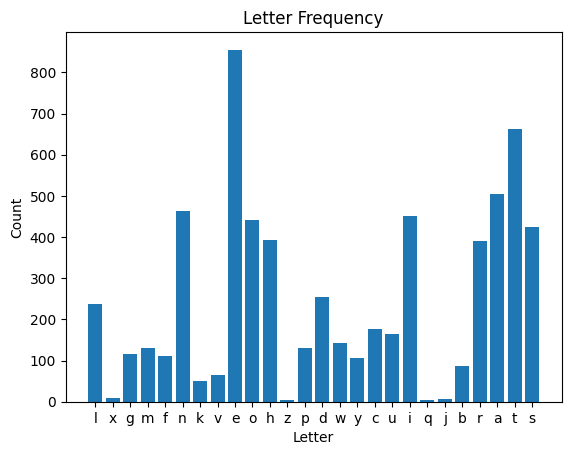

In [58]:
import matplotlib.pyplot as plt
pdf = letter_counts.toPandas()

plt.bar(pdf['letter'], pdf['count'])
plt.xlabel('Letter')
plt.ylabel('Count')
plt.title('Letter Frequency')
plt.show()